# ゼロから作る Deep Learning ❸ 輪読会
## 第 5 ステージ「DeZero で挑む」― ステップ 57 〜 60

### これまでの内容
- 第 1〜3 ステージ：自動微分・高階微分 (`Variable`/`Function`、`backward`)
- 第 4 ステージ：ニューラルネットワーク (`Layer`/`Model`/`Optimizer`、MNIST 学習)
- 第 5 ステージ前半 (52〜56)：GPU 対応・モデル保存・Dropout、そして CNN の仕組み (畳み込み・プーリングの理論)

前回の輪読会では、CNN の「仕組み」を学んだ。今回はそれを実際に DeZero で実装し、さらに時系列を扱う RNN・LSTM についても取り上げる。  

### 今日の目標 ― CNN・RNN・LSTM の実装
| ステップ | テーマ | 内容 |
|---|---|---|
| 57 | conv2d 関数と pooling 関数 | im2col で畳み込みを高速実装 |
| 58 | 代表的な CNN (VGG16) | 有名モデルの構造を理解 |
| 59 | RNN による時系列データ処理 | RNN 実装・サイン波予測・unchain |
| 60 | LSTM とデータローダ | ゲート付き RNN・時系列データローダ |

第 5 ステージを通して、DeZero は画像認識 (CNN) と時系列予測 (RNN/LSTM) の両方を扱えるようにする。

---

## 準備：これまでの DeZero を読み込む

このノートブックが単独で動くように、これまで作ってきた DeZero (自動微分・テンソル・NN 構築・Optimizer) をまとめて読み込む。

このあと、これらの内容をもとに、conv2d / pooling / RNN / LSTM を実装していく。

In [7]:
import numpy as np
import weakref
import contextlib
import matplotlib.pyplot as plt


# ===== これまで作ってきた DeZero コア =====
class Config:
    enable_backprop = True
    train = True


@contextlib.contextmanager
def using_config(name, value):
    old_value = getattr(Config, name)
    setattr(Config, name, value)
    try:
        yield
    finally:
        setattr(Config, name, old_value)


def no_grad():
    return using_config('enable_backprop', False)


def test_mode():
    return using_config('train', False)


def as_array(x):
    if np.isscalar(x):
        return np.array(x)
    return x


def as_variable(obj):
    if isinstance(obj, Variable):
        return obj
    return Variable(obj)


class Variable:
    __array_priority__ = 200

    def __init__(self, data, name=None):
        if data is not None and not isinstance(data, np.ndarray):
            raise TypeError('{} is not supported'.format(type(data)))
        self.data = data
        self.name = name
        self.grad = None
        self.creator = None
        self.generation = 0

    def set_creator(self, func):
        self.creator = func
        self.generation = func.generation + 1

    def cleargrad(self):
        self.grad = None

    @property
    def shape(self):
        return self.data.shape

    @property
    def ndim(self):
        return self.data.ndim

    @property
    def size(self):
        return self.data.size

    @property
    def dtype(self):
        return self.data.dtype

    def __len__(self):
        return len(self.data)

    def reshape(self, *shape):
        if len(shape) == 1 and isinstance(shape[0], (tuple, list)):
            shape = shape[0]
        return reshape(self, shape)

    def transpose(self, *axes):
        if len(axes) == 0:
            axes = None
        elif len(axes) == 1 and isinstance(axes[0], (tuple, list)):
            axes = axes[0]
        return transpose(self, axes)

    @property
    def T(self):
        return transpose(self)

    def sum(self, axis=None, keepdims=False):
        return sum(self, axis, keepdims)

    def max(self, axis=None, keepdims=False):
        return dz_max(self, axis, keepdims)

    def __getitem__(self, slices):
        return get_item(self, slices)

    def __repr__(self):
        if self.data is None:
            return 'variable(None)'
        p = str(self.data).replace('\n', '\n' + ' ' * 9)
        return 'variable(' + p + ')'

    def backward(self, retain_grad=False, create_graph=False):
        if self.grad is None:
            self.grad = Variable(np.ones_like(self.data))
        funcs = []
        seen_set = set()

        def add_func(f):
            if f not in seen_set:
                funcs.append(f)
                seen_set.add(f)
                funcs.sort(key=lambda x: x.generation)

        add_func(self.creator)
        while funcs:
            f = funcs.pop()
            gys = [output().grad for output in f.outputs]
            with using_config('enable_backprop', create_graph):
                gxs = f.backward(*gys)
                if not isinstance(gxs, tuple):
                    gxs = (gxs,)
                for x, gx in zip(f.inputs, gxs):
                    if x.grad is None:
                        x.grad = gx
                    else:
                        x.grad = x.grad + gx
                    if x.creator is not None:
                        add_func(x.creator)
            if not retain_grad:
                for y in f.outputs:
                    y().grad = None

    def unchain(self):
        self.creator = None

    def unchain_backward(self):
        if self.creator is not None:
            funcs = [self.creator]
            while funcs:
                f = funcs.pop()
                for x in f.inputs:
                    if x.creator is not None:
                        funcs.append(x.creator)
                        x.unchain()


class Parameter(Variable):
    pass


class Function:
    def __call__(self, *inputs):
        inputs = [as_variable(x) for x in inputs]
        xs = [x.data for x in inputs]
        ys = self.forward(*xs)
        if not isinstance(ys, tuple):
            ys = (ys,)
        outputs = [Variable(as_array(y)) for y in ys]
        if Config.enable_backprop:
            self.generation = max([x.generation for x in inputs])
            for output in outputs:
                output.set_creator(self)
            self.inputs = inputs
            self.outputs = [weakref.ref(output) for output in outputs]
        return outputs if len(outputs) > 1 else outputs[0]

    def forward(self, xs):
        raise NotImplementedError()

    def backward(self, gys):
        raise NotImplementedError()


class Add(Function):
    def forward(self, x0, x1):
        self.x0_shape, self.x1_shape = x0.shape, x1.shape
        return x0 + x1

    def backward(self, gy):
        gx0, gx1 = gy, gy
        if self.x0_shape != self.x1_shape:
            gx0 = sum_to(gx0, self.x0_shape)
            gx1 = sum_to(gx1, self.x1_shape)
        return gx0, gx1


class Mul(Function):
    def forward(self, x0, x1):
        self.x0_shape, self.x1_shape = x0.shape, x1.shape
        return x0 * x1

    def backward(self, gy):
        x0, x1 = self.inputs
        gx0, gx1 = gy * x1, gy * x0
        if self.x0_shape != self.x1_shape:
            gx0 = sum_to(gx0, self.x0_shape)
            gx1 = sum_to(gx1, self.x1_shape)
        return gx0, gx1


class Neg(Function):
    def forward(self, x):
        return -x

    def backward(self, gy):
        return -gy


class Sub(Function):
    def forward(self, x0, x1):
        self.x0_shape, self.x1_shape = x0.shape, x1.shape
        return x0 - x1

    def backward(self, gy):
        gx0, gx1 = gy, -gy
        if self.x0_shape != self.x1_shape:
            gx0 = sum_to(gx0, self.x0_shape)
            gx1 = sum_to(gx1, self.x1_shape)
        return gx0, gx1


class Div(Function):
    def forward(self, x0, x1):
        self.x0_shape, self.x1_shape = x0.shape, x1.shape
        return x0 / x1

    def backward(self, gy):
        x0, x1 = self.inputs
        gx0 = gy / x1
        gx1 = gy * (-x0 / x1**2)
        if self.x0_shape != self.x1_shape:
            gx0 = sum_to(gx0, self.x0_shape)
            gx1 = sum_to(gx1, self.x1_shape)
        return gx0, gx1


class Pow(Function):
    def __init__(self, c):
        self.c = c

    def forward(self, x):
        return x**self.c

    def backward(self, gy):
        (x,) = self.inputs
        return self.c * x ** (self.c - 1) * gy


def add(x0, x1):
    return Add()(x0, as_array(x1))


def mul(x0, x1):
    return Mul()(x0, as_array(x1))


def neg(x):
    return Neg()(x)


def sub(x0, x1):
    return Sub()(x0, as_array(x1))


def rsub(x0, x1):
    return Sub()(as_array(x1), x0)


def div(x0, x1):
    return Div()(x0, as_array(x1))


def rdiv(x0, x1):
    return Div()(as_array(x1), x0)


def pow(x, c):
    return Pow(c)(x)


Variable.__add__ = add
Variable.__radd__ = add
Variable.__mul__ = mul
Variable.__rmul__ = mul
Variable.__neg__ = neg
Variable.__sub__ = sub
Variable.__rsub__ = rsub
Variable.__truediv__ = div
Variable.__rtruediv__ = rdiv
Variable.__pow__ = pow


class Reshape(Function):
    def __init__(self, shape):
        self.shape = shape

    def forward(self, x):
        self.x_shape = x.shape
        return x.reshape(self.shape)

    def backward(self, gy):
        return reshape(gy, self.x_shape)


def reshape(x, shape):
    if x.shape == shape:
        return as_variable(x)
    return Reshape(shape)(x)


class Transpose(Function):
    def __init__(self, axes=None):
        self.axes = axes

    def forward(self, x):
        return x.transpose(self.axes)

    def backward(self, gy):
        if self.axes is None:
            return transpose(gy)
        axes_len = len(self.axes)
        inv_axes = tuple(np.argsort([ax % axes_len for ax in self.axes]))
        return transpose(gy, inv_axes)


def transpose(x, axes=None):
    return Transpose(axes)(x)


class BroadcastTo(Function):
    def __init__(self, shape):
        self.shape = shape

    def forward(self, x):
        self.x_shape = x.shape
        return np.broadcast_to(x, self.shape)

    def backward(self, gy):
        return sum_to(gy, self.x_shape)


def broadcast_to(x, shape):
    if x.shape == shape:
        return as_variable(x)
    return BroadcastTo(shape)(x)


def numpy_sum_to(x, shape):
    ndim = len(shape)
    lead = x.ndim - ndim
    lead_axis = tuple(range(lead))
    axis = tuple([i + lead for i, sx in enumerate(shape) if sx == 1])
    y = x.sum(lead_axis + axis, keepdims=True)
    if lead > 0:
        y = y.squeeze(lead_axis)
    return y


class SumTo(Function):
    def __init__(self, shape):
        self.shape = shape

    def forward(self, x):
        self.x_shape = x.shape
        return numpy_sum_to(x, self.shape)

    def backward(self, gy):
        return broadcast_to(gy, self.x_shape)


def sum_to(x, shape):
    if x.shape == shape:
        return as_variable(x)
    return SumTo(shape)(x)


def reshape_sum_backward(gy, x_shape, axis, keepdims):
    ndim = len(x_shape)
    tupled_axis = axis
    if axis is None:
        tupled_axis = None
    elif not isinstance(axis, tuple):
        tupled_axis = (axis,)
    if not (ndim == 0 or tupled_axis is None or keepdims):
        actual_axis = [a if a >= 0 else a + ndim for a in tupled_axis]
        shape = list(gy.shape)
        for a in sorted(actual_axis):
            shape.insert(a, 1)
    else:
        shape = gy.shape
    return gy.reshape(shape)


class Sum(Function):
    def __init__(self, axis, keepdims):
        self.axis = axis
        self.keepdims = keepdims

    def forward(self, x):
        self.x_shape = x.shape
        return x.sum(axis=self.axis, keepdims=self.keepdims)

    def backward(self, gy):
        gy = reshape_sum_backward(gy, self.x_shape, self.axis, self.keepdims)
        return broadcast_to(gy, self.x_shape)


def sum(x, axis=None, keepdims=False):
    return Sum(axis, keepdims)(x)


class Max(Function):
    def __init__(self, axis=None, keepdims=False):
        self.axis = axis
        self.keepdims = keepdims

    def forward(self, x):
        y = x.max(axis=self.axis, keepdims=self.keepdims)
        return y

    def backward(self, gy):
        x = self.inputs[0]
        y = self.outputs[0]()
        shape = _max_backward_shape(x, self.axis)
        gy = reshape(gy, shape)
        y = reshape(y, shape)
        cond = x.data == y.data
        gy = broadcast_to(gy, cond.shape)
        return gy * cond


def _max_backward_shape(x, axis):
    if axis is None:
        axis = range(x.ndim)
    elif isinstance(axis, int):
        axis = (axis,)
    else:
        axis = axis
    shape = [s if ax not in axis else 1 for ax, s in enumerate(x.shape)]
    return shape


def dz_max(x, axis=None, keepdims=False):
    return Max(axis, keepdims)(x)


class MatMul(Function):
    def forward(self, x, W):
        return x.dot(W)

    def backward(self, gy):
        x, W = self.inputs
        return matmul(gy, W.T), matmul(x.T, gy)


def matmul(x, W):
    return MatMul()(x, W)


class Linear(Function):
    def forward(self, x, W, b):
        y = x.dot(W)
        if b is not None:
            y += b
        return y

    def backward(self, gy):
        x, W, b = self.inputs
        gb = None if b.data is None else sum_to(gy, b.shape)
        gx = matmul(gy, W.T)
        gW = matmul(x.T, gy)
        return gx, gW, gb


def linear(x, W, b=None):
    return Linear()(x, W, b)


class Exp(Function):
    def forward(self, x):
        return np.exp(x)

    def backward(self, gy):
        y = self.outputs[0]()
        return gy * y


def exp(x):
    return Exp()(x)


class Log(Function):
    def forward(self, x):
        return np.log(x)

    def backward(self, gy):
        (x,) = self.inputs
        return gy / x


def log(x):
    return Log()(x)


class Tanh(Function):
    def forward(self, x):
        return np.tanh(x)

    def backward(self, gy):
        y = self.outputs[0]()
        return gy * (1 - y * y)


def tanh(x):
    return Tanh()(x)


class Sigmoid(Function):
    def forward(self, x):
        return 1 / (1 + np.exp(-x))

    def backward(self, gy):
        y = self.outputs[0]()
        return gy * y * (1 - y)


def sigmoid(x):
    return Sigmoid()(x)


class ReLU(Function):
    def forward(self, x):
        return np.maximum(x, 0.0)

    def backward(self, gy):
        (x,) = self.inputs
        mask = x.data > 0
        return gy * mask


def relu(x):
    return ReLU()(x)


class GetItem(Function):
    def __init__(self, slices):
        self.slices = slices

    def forward(self, x):
        return x[self.slices]

    def backward(self, gy):
        (x,) = self.inputs
        f = GetItemGrad(self.slices, x.shape)
        return f(gy)


class GetItemGrad(Function):
    def __init__(self, slices, in_shape):
        self.slices = slices
        self.in_shape = in_shape

    def forward(self, gy):
        gx = np.zeros(self.in_shape, dtype=gy.dtype)
        np.add.at(gx, self.slices, gy)
        return gx

    def backward(self, ggx):
        return get_item(ggx, self.slices)


def get_item(x, slices):
    return GetItem(slices)(x)


class Clip(Function):
    def __init__(self, x_min, x_max):
        self.x_min = x_min
        self.x_max = x_max

    def forward(self, x):
        return np.clip(x, self.x_min, self.x_max)

    def backward(self, gy):
        (x,) = self.inputs
        mask = (x.data >= self.x_min) * (x.data <= self.x_max)
        return gy * mask


def clip(x, x_min, x_max):
    return Clip(x_min, x_max)(x)


def softmax(x, axis=1):
    x = as_variable(x)
    y = exp(x - x.data.max(axis=axis, keepdims=True))
    return y / sum(y, axis=axis, keepdims=True)


def softmax_cross_entropy(x, t):
    x, t = as_variable(x), as_variable(t)
    N = x.shape[0]
    p = clip(softmax(x), 1e-15, 1.0)
    log_p = log(p)
    tlog_p = log_p[np.arange(N), t.data]
    return -1 * sum(tlog_p) / N


def mean_squared_error(x0, x1):
    x0, x1 = as_variable(x0), as_variable(x1)
    diff = x0 - x1
    return sum(diff**2) / len(diff)


def accuracy(y, t):
    y, t = as_variable(y), as_variable(t)
    pred = y.data.argmax(axis=1).reshape(t.shape)
    return Variable(as_array((pred == t.data).mean()))


# ===== im2col (ステップ 57 で使う)=====
def pair(x):
    if isinstance(x, int):
        return (x, x)
    return x


def get_conv_outsize(input_size, kernel_size, stride, pad):
    return (input_size + pad * 2 - kernel_size) // stride + 1


class Im2col(Function):
    def __init__(self, kernel_size, stride, pad, to_matrix):
        self.kernel_size = kernel_size
        self.stride = stride
        self.pad = pad
        self.to_matrix = to_matrix
        self.input_shape = None

    def forward(self, x):
        self.input_shape = x.shape
        y = _im2col_array(x, self.kernel_size, self.stride, self.pad, self.to_matrix)
        return y

    def backward(self, gy):
        gx = col2im(
            gy,
            self.input_shape,
            self.kernel_size,
            self.stride,
            self.pad,
            self.to_matrix,
        )
        return gx


def im2col(x, kernel_size, stride=1, pad=0, to_matrix=True):
    return Im2col(kernel_size, stride, pad, to_matrix)(x)


class Col2im(Function):
    def __init__(self, input_shape, kernel_size, stride, pad, to_matrix):
        self.input_shape = input_shape
        self.kernel_size = kernel_size
        self.stride = stride
        self.pad = pad
        self.to_matrix = to_matrix

    def forward(self, x):
        return _col2im_array(
            x, self.input_shape, self.kernel_size, self.stride, self.pad, self.to_matrix
        )

    def backward(self, gy):
        return im2col(gy, self.kernel_size, self.stride, self.pad, self.to_matrix)


def col2im(x, input_shape, kernel_size, stride=1, pad=0, to_matrix=True):
    return Col2im(input_shape, kernel_size, stride, pad, to_matrix)(x)


def _im2col_array(img, kernel_size, stride, pad, to_matrix=True):
    N, C, H, W = img.shape
    KH, KW = pair(kernel_size)
    SH, SW = pair(stride)
    PH, PW = pair(pad)
    OH = get_conv_outsize(H, KH, SH, PH)
    OW = get_conv_outsize(W, KW, SW, PW)
    img = np.pad(img, ((0, 0), (0, 0), (PH, PH), (PW, PW)), mode='constant')
    col = np.ndarray((N, C, KH, KW, OH, OW), dtype=img.dtype)
    for j in range(KH):
        j_lim = j + SH * OH
        for i in range(KW):
            i_lim = i + SW * OW
            col[:, :, j, i, :, :] = img[:, :, j:j_lim:SH, i:i_lim:SW]
    if to_matrix:
        col = col.transpose((0, 4, 5, 1, 2, 3)).reshape((N * OH * OW, -1))
    return col


def _col2im_array(col, img_shape, kernel_size, stride, pad, to_matrix=True):
    N, C, H, W = img_shape
    KH, KW = pair(kernel_size)
    SH, SW = pair(stride)
    PH, PW = pair(pad)
    OH = get_conv_outsize(H, KH, SH, PH)
    OW = get_conv_outsize(W, KW, SW, PW)
    if to_matrix:
        col = col.reshape(N, OH, OW, C, KH, KW).transpose(0, 3, 4, 5, 1, 2)
    img = np.zeros((N, C, H + 2 * PH + SH - 1, W + 2 * PW + SW - 1), dtype=col.dtype)
    for j in range(KH):
        j_lim = j + SH * OH
        for i in range(KW):
            i_lim = i + SW * OW
            img[:, :, j:j_lim:SH, i:i_lim:SW] += col[:, :, j, i, :, :]
    return img[:, :, PH : H + PH, PW : W + PW]


# ===== Layer / Model / Optimizer =====
class Layer:
    def __init__(self):
        self._params = set()

    def __setattr__(self, name, value):
        if isinstance(value, (Parameter, Layer)):
            self._params.add(name)
        super().__setattr__(name, value)

    def __call__(self, *inputs):
        outputs = self.forward(*inputs)
        if not isinstance(outputs, tuple):
            outputs = (outputs,)
        return outputs if len(outputs) > 1 else outputs[0]

    def forward(self, inputs):
        raise NotImplementedError()

    def params(self):
        for name in self._params:
            obj = self.__dict__[name]
            if isinstance(obj, Layer):
                yield from obj.params()
            else:
                yield obj

    def cleargrads(self):
        for param in self.params():
            param.cleargrad()


class LinearLayer(Layer):
    def __init__(self, out_size, nobias=False, in_size=None):
        super().__init__()
        self.in_size = in_size
        self.out_size = out_size
        self.W = Parameter(None, name='W')
        if self.in_size is not None:
            self._init_W()
        self.b = (
            None
            if nobias
            else Parameter(np.zeros(out_size, dtype=np.float32), name='b')
        )

    def _init_W(self):
        I, O = self.in_size, self.out_size
        self.W.data = (np.random.randn(I, O) * np.sqrt(1 / I)).astype(np.float32)

    def forward(self, x):
        if self.W.data is None:
            self.in_size = x.shape[1]
            self._init_W()
        return linear(x, self.W, self.b)


class Model(Layer):
    def plot(self, *inputs):
        pass


class MLP(Model):
    def __init__(self, fc_output_sizes, activation=sigmoid):
        super().__init__()
        self.activation = activation
        self.layers = []
        for i, out_size in enumerate(fc_output_sizes):
            layer = LinearLayer(out_size)
            setattr(self, 'l' + str(i), layer)
            self.layers.append(layer)

    def forward(self, x):
        for l in self.layers[:-1]:
            x = self.activation(l(x))
        return self.layers[-1](x)


class Optimizer:
    def __init__(self):
        self.target = None

    def setup(self, target):
        self.target = target
        return self

    def update(self):
        params = [p for p in self.target.params() if p.grad is not None]
        for param in params:
            self.update_one(param)

    def update_one(self, param):
        raise NotImplementedError()


class SGD(Optimizer):
    def __init__(self, lr=0.01):
        super().__init__()
        self.lr = lr

    def update_one(self, param):
        param.data -= self.lr * param.grad.data


class MomentumSGD(Optimizer):
    def __init__(self, lr=0.01, momentum=0.9):
        super().__init__()
        self.lr = lr
        self.momentum = momentum
        self.vs = {}

    def update_one(self, param):
        k = id(param)
        if k not in self.vs:
            self.vs[k] = np.zeros_like(param.data)
        v = self.vs[k]
        v *= self.momentum
        v -= self.lr * param.grad.data
        param.data += v


class Adam(Optimizer):
    def __init__(self, alpha=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__()
        self.alpha = alpha
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        self.ms = {}
        self.vs = {}

    def update(self):
        self.t += 1
        super().update()

    def update_one(self, param):
        k = id(param)
        if k not in self.ms:
            self.ms[k] = np.zeros_like(param.data)
            self.vs[k] = np.zeros_like(param.data)
        m, v = self.ms[k], self.vs[k]
        grad = param.grad.data
        m += (1 - self.beta1) * (grad - m)
        v += (1 - self.beta2) * (grad * grad - v)
        mhat = m / (1 - self.beta1**self.t)
        vhat = v / (1 - self.beta2**self.t)
        param.data -= self.alpha * mhat / (np.sqrt(vhat) + self.eps)


conv/RNN/LSTM に対応する DeZero コア () を読み込んだ。

---
# ステップ 57：conv2d 関数と pooling 関数

前回 (ステップ 55・56) は、畳み込みとプーリングの「仕組み」を理解した。今回はそれを DeZero で実装する。ポイントは im2col という、畳み込みを高速に計算するテクニックである。

## 57.1 im2col による展開

畳み込み演算は「フィルターを画像上で移動しながら、各位置で積和を計算する」ものだった。これを素朴に `for` ループで書くと、非常に遅くなる (前回の `conv2d_naive` を参照)。

そこで im2col (image to column) という工夫を使う。

これは、フィルターが重なる各領域を 1 本の行に引き伸ばして並べ、大きな行列を作り、畳み込みが 1 回の行列の積で計算できるようにするものである。

行列の積は NumPy が高度に最適化しているため、この工夫により、`for` ループより圧倒的に速くなる。

具体的には、入力画像 $(N, C, H, W)$ (データ数・チャンネル・縦・横) を、im2col で $(N \times OH \times OW,\ C \times KH \times KW)$ という 2 次元行列に変換する。各行が「フィルターが 1 回重なる領域」を平らにしたものである。

まず `im2col` を実装する。少し複雑だが、「各フィルター位置の領域を集めて並べる」処理である。

In [8]:
def get_conv_outsize(input_size, kernel_size, stride, pad):
    # 畳み込み後の出力サイズ (前回の式)：(H + 2P - FH)/S + 1
    return (input_size + pad * 2 - kernel_size) // stride + 1

def pair(x):
    # 3 -> (3,3) のように、単一の値を (縦, 横) のペアにする補助関数
    if isinstance(x, int):
        return (x, x)
    return x

def im2col_array(img, kernel_size, stride, pad):
    # img：(N, C, H, W) を (N, C, KH, KW, OH, OW) の 6 次元に展開する
    N, C, H, W = img.shape
    KH, KW = pair(kernel_size)
    SH, SW = pair(stride)
    PH, PW = pair(pad)
    OH = get_conv_outsize(H, KH, SH, PH)   # 出力の縦
    OW = get_conv_outsize(W, KW, SW, PW)   # 出力の横

    # 画像の周囲をパディング (0 で埋める)
    img = np.pad(img, ((0,0),(0,0),(PH,PH),(PW,PW)), mode='constant')
    col = np.ndarray((N, C, KH, KW, OH, OW), dtype=img.dtype)

    # フィルター内の各位置 (j,i) について、対応する画素をまとめて取り出す
    for j in range(KH):
        j_lim = j + SH * OH
        for i in range(KW):
            i_lim = i + SW * OW
            col[:, :, j, i, :, :] = img[:, :, j:j_lim:SH, i:i_lim:SW]
    return col

# 動作確認：4x4 画像を 3x3 フィルターで展開
np.random.seed(0)
img = np.random.rand(1, 1, 4, 4)   # N=1, C=1, 4x4
col = im2col_array(img, kernel_size=3, stride=1, pad=0)
print("入力画像の形状：", img.shape)
print("im2col 後の形状：", col.shape, " (N, C, KH, KW, OH, OW)")


入力画像の形状： (1, 1, 4, 4)
im2col 後の形状： (1, 1, 3, 3, 2, 2)  (N, C, KH, KW, OH, OW)


出力サイズ OH=OW=2、各位置の 3x3 領域が展開された

## 57.2 conv2d 関数の実装

`im2col` で展開した行列と、フィルターを平らにした行列を掛け算すれば、畳み込みが一気に計算できる。

- 入力を im2col で $(N \cdot OH \cdot OW,\ C \cdot KH \cdot KW)$ に。
- フィルター $(OC, C, KH, KW)$ を $(C \cdot KH \cdot KW,\ OC)$ に平らに。
- この 2 つを行列の積 → $(N \cdot OH \cdot OW,\ OC)$。
- 形を $(N, OC, OH, OW)$ に戻す。

ここで $OC$ は出力チャンネル数 (フィルターの枚数) である。DeZero の `Variable` を使って、逆伝播もできる形で実装する (逆伝播の細部は複雑なので、ここでは順伝播を中心に、DeZero の関数を組み合わせて実現する)。

In [9]:
# DeZero の関数を組み合わせて conv2d を実装 (逆伝播は自動微分に任せる)
def conv2d_simple(x, W, b=None, stride=1, pad=0):
    # x: Variable (N, C, H, W), W: Variable (OC, C, KH, KW)
    x = as_variable(x)
    Weight = W
    N, C, H, Wid = x.shape
    OC, C, KH, KW = Weight.shape
    SH, SW = pair(stride)
    PH, PW = pair(pad)
    OH = get_conv_outsize(H, KH, SH, PH)
    OW = get_conv_outsize(Wid, KW, SW, PW)

    # 1. im2col で入力を展開 (DeZero の im2col 関数を使う)
    col = im2col(x, (KH, KW), stride, pad, to_matrix=True)  # (N*OH*OW, C*KH*KW)
    # 2. フィルターを平らにする
    Weight = Weight.reshape(OC, -1).transpose()            # (C*KH*KW, OC)
    # 3. 行列の積 (＝畳み込み)
    t = linear(col, Weight, b)                             # (N*OH*OW, OC)
    # 4. 形を戻す
    y = t.reshape(N, OH, OW, OC).transpose(0, 3, 1, 2)     # (N, OC, OH, OW)
    return y

# 動作確認
np.random.seed(0)
x = Variable(np.random.rand(1, 3, 7, 7).astype(np.float32))  # 1 枚、3ch、7x7
W = Variable(np.random.rand(5, 3, 3, 3).astype(np.float32))  # 5 枚のフィルター、3ch、3x3
b = Variable(np.zeros(5).astype(np.float32))
y = conv2d_simple(x, W, b, stride=1, pad=1)
print("入力：", x.shape, " フィルター：", W.shape)
print("畳み込み出力：", y.shape, " (1 枚, 5ch, 7x7)  ※pad=1 で縦横サイズ維持")

# 逆伝播も動く (自動微分)
y.backward()
print("逆伝播 OK：x.grad", x.shape, ", W.grad", W.shape)


入力： (1, 3, 7, 7)  フィルター： (5, 3, 3, 3)
畳み込み出力： (1, 5, 7, 7)  (1 枚, 5ch, 7x7)  ※pad=1 で縦横サイズ維持
逆伝播 OK：x.grad (1, 3, 7, 7) , W.grad (5, 3, 3, 3)


`pad=1` にしたので、出力の縦横サイズが入力と同じ 7×7 に保たれている。出力チャンネル数は 5 (フィルター 5 枚) である。そして `backward()` も動き、フィルター `W` の勾配が自動で求まる。これで学習可能な畳み込み層ができた。

## 57.4 pooling 関数の実装

プーリングも im2col で実装できる。各プーリング領域を展開し、その最大値を取る (Max プーリング)。ただ最大値を取るだけなので、プーリングには学習パラメータが無い。なので、実装はシンプルである。

In [10]:
def pooling_simple(x, kernel_size, stride=1, pad=0):
    x = as_variable(x)
    N, C, H, W = x.shape
    KH, KW = pair(kernel_size)
    PH, PW = pair(pad)
    SH, SW = pair(stride)
    OH = get_conv_outsize(H, KH, SH, PH)
    OW = get_conv_outsize(W, KW, SW, PW)

    # im2col で展開してから、各領域の最大値を取る
    col = im2col(x, kernel_size, stride, pad, to_matrix=False)  # (N,C,KH,KW,OH,OW)
    col = col.reshape(N, C, KH * KW, OH, OW)
    y = col.max(axis=2)   # KH*KW の中の最大値 (Max プーリング)
    return y

# 動作確認：4x4 を 2x2 プーリングで 2x2 に
x = Variable(np.array([[[[1, 2, 3, 0],
                         [4, 5, 6, 1],
                         [7, 8, 9, 2],
                         [0, 1, 2, 3]]]], dtype=np.float32))  # (1,1,4,4)
y = pooling_simple(x, kernel_size=2, stride=2)
print("入力 (4x4)：\n", x.data[0, 0])
print("\nMax プーリング後 (2x2)：\n", y.data[0, 0])
print("\n左上ブロック max(1,2,4,5) =", y.data[0,0,0,0])


入力 (4x4)：
 [[1. 2. 3. 0.]
 [4. 5. 6. 1.]
 [7. 8. 9. 2.]
 [0. 1. 2. 3.]]

Max プーリング後 (2x2)：
 [[5. 6.]
 [8. 9.]]

左上ブロック max(1,2,4,5) = 5.0


4×4 が 2×2 に縮小され、各ブロックの最大値が取られている。

> ステップ 57 のまとめ
> - im2col：フィルターが重なる領域を 1 行に展開し、畳み込みを行列の積に変換して高速化。
> - `conv2d`：im2col + 行列の積で畳み込みを実装。逆伝播は自動微分に任せる。
> - `pooling`：領域を展開して最大値を取る (Max プーリング)。
> - これで DeZero に学習可能な畳み込み層・プーリング層が加わった。

---
# ステップ 58：代表的な CNN (VGG16)

畳み込み・プーリングが実装できたので、それらを積み重ねた本格的な CNN を実装してみる。ここでは有名なモデル VGG16 を取り上げる。

## 58.1 VGG16 とは

VGG16 は、2014 年に発表された画像認識モデルで、そのシンプルで規則的な構造から今でも教材や特徴抽出によく使われる。「16」は、重みを持つ層 (畳み込み層＋全結合層) が 16 層あることを表す。

VGG16 の特徴：
- 3×3 の小さな畳み込みフィルターだけを使う (シンプル)。
- 畳み込みを数回重ねてはプーリングで半分に縮小、を繰り返す。
- 最後に全結合層で 1000 クラス (ImageNet というデータセットの分類) に分類。

構造を整理すると、次のような繰り返しである。

In [11]:
# VGG16 の構造を (層のリストとして) 表示する
vgg16_structure = [
    ("入力",           "(3, 224, 224)  カラー画像"),
    ("Conv 3x3, 64",   "→ (64, 224, 224)"),
    ("Conv 3x3, 64",   "→ (64, 224, 224)"),
    ("MaxPool 2x2",    "→ (64, 112, 112)  半分に縮小"),
    ("Conv 3x3, 128",  "→ (128, 112, 112)"),
    ("Conv 3x3, 128",  "→ (128, 112, 112)"),
    ("MaxPool 2x2",    "→ (128, 56, 56)"),
    ("Conv 3x3, 256 x3", "→ (256, 56, 56)"),
    ("MaxPool 2x2",    "→ (256, 28, 28)"),
    ("Conv 3x3, 512 x3", "→ (512, 28, 28)"),
    ("MaxPool 2x2",    "→ (512, 14, 14)"),
    ("Conv 3x3, 512 x3", "→ (512, 14, 14)"),
    ("MaxPool 2x2",    "→ (512, 7, 7)"),
    ("Flatten",        "→ (25088,)  平らにする"),
    ("Linear 4096",    "→ (4096,)  全結合"),
    ("Linear 4096",    "→ (4096,)"),
    ("Linear 1000",    "→ (1000,)  1000 クラス分類"),
]
print("=" * 55)
print("VGG16 の構造 (畳み込み→プーリングの繰り返し)")
print("=" * 55)
for name, shape in vgg16_structure:
    print(f"  {name:20s} {shape}")
print("=" * 55)

VGG16 の構造 (畳み込み→プーリングの繰り返し)
  入力                   (3, 224, 224)  カラー画像
  Conv 3x3, 64         → (64, 224, 224)
  Conv 3x3, 64         → (64, 224, 224)
  MaxPool 2x2          → (64, 112, 112)  半分に縮小
  Conv 3x3, 128        → (128, 112, 112)
  Conv 3x3, 128        → (128, 112, 112)
  MaxPool 2x2          → (128, 56, 56)
  Conv 3x3, 256 x3     → (256, 56, 56)
  MaxPool 2x2          → (256, 28, 28)
  Conv 3x3, 512 x3     → (512, 28, 28)
  MaxPool 2x2          → (512, 14, 14)
  Conv 3x3, 512 x3     → (512, 14, 14)
  MaxPool 2x2          → (512, 7, 7)
  Flatten              → (25088,)  平らにする
  Linear 4096          → (4096,)  全結合
  Linear 4096          → (4096,)
  Linear 1000          → (1000,)  1000 クラス分類


特徴：3x3 畳み込みを重ね、プーリングで縮小。奥へ行くほど  

チャンネル数を増やし(64→128→256→512)、空間サイズを縮小  

## 58.2〜58.3 学習済み重みと VGG16 の利用について

VGG16 を一から学習するには、ImageNet (120 万枚以上の画像) で数日かかる。そのため実務では、学習済みの重み (すでに訓練されたパラメータ) をダウンロードして使うのが普通である。ステップ 53 で学んだ「パラメータの保存・読み込み」が、まさにここで活きる。

```python
# 書籍での使い方 (イメージ)
model = VGG16(pretrained=True)   # 学習済み重みを自動ダウンロード
model.to_gpu()
y = model(img)                   # 画像を入れると 1000 クラスの予測が出る
```

本輪読会では、大きな重みのダウンロードは行わない。その代わり、VGG16 と同じ設計思想 (3×3 畳み込み＋プーリングの繰り返し) の小さな CNN を作り、手書き数字 (8×8) で実際に動かして、CNN の構造を体感する。

### 実装のテスト①：VGG 風の小型 CNN を作って手書き数字を分類

VGG の「畳み込み → 畳み込み → プーリング」という構造を真似た小さな CNN を作り、手書き数字 (8×8) で学習させる。全結合層だけの MLP と精度を比べ、CNN が画像に強いことを確認する。

In [12]:
from sklearn.datasets import load_digits

# データ準備：8x8 手書き数字を (N, 1, 8, 8) の画像形式に
digits = load_digits()
X = digits.data.reshape(-1, 1, 8, 8).astype(np.float32) / 16.0  # チャンネル 1 の画像
y = digits.target.astype(int)
X_train, y_train = X[:1200], y[:1200]
X_test, y_test = X[1200:1500], y[1200:1500]
print("画像データの形状：", X_train.shape, " (N, チャンネル, 縦, 横)")

# VGG 風の小型 CNN (畳み込み 2 回 → プーリング → 全結合)
class SmallCNN(Model):
    def __init__(self):
        super().__init__()
        # 畳み込み層のフィルターを Parameter として持つ
        # W1：8 枚のフィルター、入力 1ch、3x3
        self.conv1_W = Parameter((np.random.randn(8, 1, 3, 3) * np.sqrt(2/9)).astype(np.float32), name='c1W')
        self.conv1_b = Parameter(np.zeros(8, dtype=np.float32), name='c1b')
        # W2：16 枚、入力 8ch、3x3
        self.conv2_W = Parameter((np.random.randn(16, 8, 3, 3) * np.sqrt(2/(8*9))).astype(np.float32), name='c2W')
        self.conv2_b = Parameter(np.zeros(16, dtype=np.float32), name='c2b')
        # 全結合層
        self.fc = LinearLayer(10)

    def forward(self, x):
        # 畳み込み → ReLU → 畳み込み → ReLU → プーリング → 全結合
        h = relu(conv2d_simple(x, self.conv1_W, self.conv1_b, stride=1, pad=1))  # (N,8,8,8)
        h = relu(conv2d_simple(h, self.conv2_W, self.conv2_b, stride=1, pad=1))  # (N,16,8,8)
        h = pooling_simple(h, kernel_size=2, stride=2)                           # (N,16,4,4)
        h = h.reshape(h.shape[0], -1)   # 平らにする (N, 16*4*4=256)
        return self.fc(h)

np.random.seed(0)
model = SmallCNN()
optimizer = MomentumSGD(lr=0.1).setup(model)

# 学習 (小規模・少エポック)
batch_size = 100
for epoch in range(10):
    idx = np.random.permutation(len(X_train))
    sum_loss = 0
    for i in range(0, len(X_train), batch_size):
        bi = idx[i:i+batch_size]
        bx, bt = Variable(X_train[bi]), Variable(y_train[bi])
        y_pred = model(bx)
        loss = softmax_cross_entropy(y_pred, bt)
        model.cleargrads()
        loss.backward()
        optimizer.update()
        sum_loss += float(loss.data) * len(bi)
    if (epoch+1) % 2 == 0:
        with no_grad():
            acc = accuracy(model(Variable(X_test)), Variable(y_test))
        print(f"epoch {epoch+1}: loss={sum_loss/len(X_train):.3f}, test_acc={float(acc.data):.3f}")


画像データの形状： (1200, 1, 8, 8)  (N, チャンネル, 縦, 横)
epoch 2: loss=0.802, test_acc=0.847
epoch 4: loss=0.104, test_acc=0.933
epoch 6: loss=0.039, test_acc=0.953
epoch 8: loss=0.016, test_acc=0.953
epoch 10: loss=0.004, test_acc=0.957


VGG 風の小型 CNN で手書き数字を分類できた。

小さな CNN でも、畳み込み → プーリング → 全結合という VGG と同じ構造で、手書き数字を高い精度で分類できた。VGG16 は、これを遥かに大規模にしたもの (フィルター数を増やし、層を深くしたもの) である。基本の考え方は同じであることが体感できる。

> ステップ 58 のまとめ
> - VGG16：3×3 畳み込みを重ね、プーリングで縮小する規則的な構造の有名 CNN。
> - 奥へ行くほどチャンネルを増やし (64→512)、空間サイズを縮小。
> - 実務では学習済み重みをロードして使う (ステップ 53 の保存/読込が活きる)。
> - VGG 風の小型 CNN を実装し、手書き数字を分類できることを確認。

---
# ステップ 59：RNN による時系列データ処理

ここまでは画像 (CNN) を扱ってきた。ここからは時系列データ (順番に意味があるデータ) を扱う RNN (Recurrent Neural Network、再帰型ニューラルネットワーク) を実装する。

## 59.1 RNN とは

RNN は、文章・音声・株価・センサー値のような「順番に並んだデータ」を扱うのが得意である。ポイントは隠れ状態 (hidden state) という「記憶」を持ち、それを次の時刻へ引き継ぐことである。

普通のニューラルネットワークは、入力ごとに独立して処理する。一方 RNN は、前の時刻の情報を覚えたまま次の入力を処理する。これにより「文脈」を捉えられる。

RNN の 1 ステップの計算は次の式である。

$$ h_t = \tanh(x_t W_x + h_{t-1} W_h + b) $$

- $x_t$：時刻 $t$ の入力。
- $h_{t-1}$：前の時刻の隠れ状態 (＝これまでの記憶)。
- $h_t$：今の時刻の隠れ状態 (次の時刻へ引き継ぐ)。
- $W_x$：入力用の重み、$W_h$：隠れ状態用の重み、$b$：バイアス。
- $\tanh$：活性化関数 ($-1〜1$ に収める)。

式の解釈：「今の入力 $x_t$」と「これまでの記憶 $h_{t-1}$」を混ぜ合わせて、新しい記憶 $h_t$ を作る。この $h_t$ が次の時刻へ渡り、記憶が伝わっていくイメージ。

## 59.1 RNN レイヤの実装

RNN レイヤを実装する。内部に 2 つの全結合層 ($x \to h$ 用と $h \to h$ 用) を持ち、隠れ状態 `self.h` を保持する。`reset_state()` で記憶をリセットできるようにする。

In [13]:
class RNNLayer(Layer):
    def __init__(self, hidden_size, in_size=None):
        super().__init__()
        # 入力 x → 隠れ状態 h への変換 (バイアスあり)
        self.x2h = LinearLayer(hidden_size, in_size=in_size)
        # 前の隠れ状態 h → 新しい h への変換 (バイアスなし。x2h 側に含めるため)
        self.h2h = LinearLayer(hidden_size, in_size=hidden_size, nobias=True)
        self.h = None   # 隠れ状態 (記憶)

    def reset_state(self):
        self.h = None   # 記憶をリセット

    def forward(self, x):
        if self.h is None:
            # 最初の時刻：前の記憶が無いので x だけから作る
            h_new = tanh(self.x2h(x))
        else:
            # 2 回目以降：今の入力 x と前の記憶 h を混ぜる
            h_new = tanh(self.x2h(x) + self.h2h(self.h))
        self.h = h_new   # 記憶を更新 (次の時刻へ引き継ぐ)
        return h_new

# 動作確認：隠れ状態が引き継がれる様子
np.random.seed(0)
rnn = RNNLayer(hidden_size=5)
x1 = Variable(np.random.randn(1, 3).astype(np.float32))
x2 = Variable(np.random.randn(1, 3).astype(np.float32))
h1 = rnn(x1)   # 1 ステップ目
h2 = rnn(x2)   # 2 ステップ目 (h1 を引き継ぐ)
print("入力の次元：", x1.shape)
print("1 ステップ目の隠れ状態 h1：", h1.shape)
print("2 ステップ目の隠れ状態 h2：", h2.shape)


入力の次元： (1, 3)
1 ステップ目の隠れ状態 h1： (1, 5)
2 ステップ目の隠れ状態 h2： (1, 5)


h2 は内部で h1 を引き継いで計算されている (記憶の連鎖)

## 59.2 RNN モデルの実装

RNN レイヤの上に全結合層を乗せ、予測値を出力するモデルを作る。時系列の各時刻で「次の値」を予測するモデルである。

In [14]:
class SimpleRNN(Model):
    def __init__(self, hidden_size, out_size):
        super().__init__()
        self.rnn = RNNLayer(hidden_size)   # RNN 層
        self.fc = LinearLayer(out_size)    # 出力用の全結合層
    def reset_state(self):
        self.rnn.reset_state()
    def forward(self, x):
        h = self.rnn(x)      # 隠れ状態を更新
        y = self.fc(h)       # 隠れ状態から予測値を出す
        return y

model = SimpleRNN(hidden_size=10, out_size=1)


RNN モデルを作成した (RNN 層 + 全結合層)

## 59.3 「つながり」を切るためのメソッド unchain

時系列が長いと、計算グラフがどんどん長くなる。時刻 1000 まで処理すると、1000 ステップ分の計算グラフがつながり、逆伝播が非常に重くなる (メモリも大量消費)。

そこで Truncated BPTT (切り詰めた逆伝播) を使う。「一定のステップごとに、計算グラフのつながりを切る」のである。この「切る」操作が `unchain_backward()` である (準備セルの `Variable` に実装済み)。

`unchain_backward()` は、その変数から過去に向かって `creator` (生みの親の関数) のつながりを断ち切る。これにより、逆伝播がそこで止まり、計算量とメモリを抑えられる。

> イメージ：長い鎖 (計算グラフ) を、一定の長さで区切って切り離す。切った後は、その区間だけで逆伝播すればよいので軽くなる。記憶 (隠れ状態の値) 自体は残るので、予測は続けられる。

## 59.4 サイン波の予測

RNN でサイン波 ($\sin$ カーブ) の次の値を予測させる。時系列予測の基本的な例である。「今の値」から「次の値」を予測するように学習する。

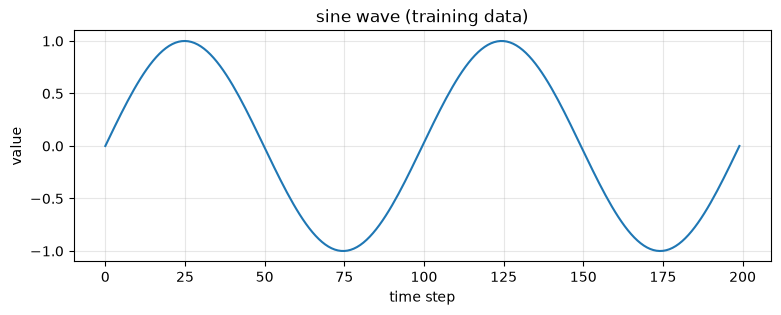

In [15]:
# サイン波データを作る
np.random.seed(0)
num_data = 200
xs_sin = np.linspace(0, 4 * np.pi, num_data)
seq = np.sin(xs_sin).astype(np.float32)

plt.figure(figsize=(9, 3))
plt.plot(seq)
plt.title('sine wave (training data)')
plt.xlabel('time step'); plt.ylabel('value')
plt.grid(alpha=0.3)
plt.show()


このサイン波の『次の値』を予測できるよう RNN を学習させる

In [16]:
# RNN の学習 (サイン波の次の値を予測)
np.random.seed(0)
model = SimpleRNN(hidden_size=50, out_size=1)
optimizer = SGD(lr=0.001).setup(model)

bptt_length = 30    # この長さごとに計算グラフを切る (Truncated BPTT)
max_epoch = 500

loss_history = []
for epoch in range(max_epoch):
    model.reset_state()      # エポックの最初に記憶をリセット
    loss, count = 0, 0

    for t in range(len(seq) - 1):
        x = Variable(seq[t].reshape(1, 1))        # 今の値
        target = Variable(seq[t + 1].reshape(1, 1))  # 次の値 (正解)

        y = model(x)                    # 予測
        loss = loss + mean_squared_error(y, target)  # 損失を積み上げる
        count += 1

        # bptt_length ごと、または最後で、逆伝播＆つながりを切る
        if count % bptt_length == 0 or t == len(seq) - 2:
            model.cleargrads()
            loss.backward()             # ここまでの区間で逆伝播
            loss.unchain_backward()     # 計算グラフのつながりを切る (Truncated BPTT)
            optimizer.update()
            loss = 0                    # 損失をリセット

    # 評価：全体の予測誤差
    model.reset_state()
    with no_grad():
        total = 0
        for t in range(len(seq) - 1):
            y = model(Variable(seq[t].reshape(1, 1)))
            total += (float(y.data.reshape(-1)[0]) - seq[t + 1]) ** 2
    loss_history.append(total / (len(seq) - 1))
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1}: loss = {loss_history[-1]:.5f}")

print(f"\n初期 loss {loss_history[0]:.5f} → 最終 loss {loss_history[-1]:.5f}")


epoch 10: loss = 0.00201
epoch 20: loss = 0.00103
epoch 30: loss = 0.00064
epoch 40: loss = 0.00045
epoch 50: loss = 0.00035
epoch 60: loss = 0.00030
epoch 70: loss = 0.00026
epoch 80: loss = 0.00023
epoch 90: loss = 0.00021
epoch 100: loss = 0.00019
epoch 110: loss = 0.00018
epoch 120: loss = 0.00016
epoch 130: loss = 0.00015
epoch 140: loss = 0.00014
epoch 150: loss = 0.00013
epoch 160: loss = 0.00013
epoch 170: loss = 0.00012
epoch 180: loss = 0.00011
epoch 190: loss = 0.00011
epoch 200: loss = 0.00010
epoch 210: loss = 0.00010
epoch 220: loss = 0.00009
epoch 230: loss = 0.00009
epoch 240: loss = 0.00008
epoch 250: loss = 0.00008
epoch 260: loss = 0.00008
epoch 270: loss = 0.00007
epoch 280: loss = 0.00007
epoch 290: loss = 0.00007
epoch 300: loss = 0.00006
epoch 310: loss = 0.00006
epoch 320: loss = 0.00006
epoch 330: loss = 0.00006
epoch 340: loss = 0.00005
epoch 350: loss = 0.00005
epoch 360: loss = 0.00005
epoch 370: loss = 0.00005
epoch 380: loss = 0.00005
epoch 390: loss = 0.0

学習した RNN で予測させ、本物のサイン波と比べる。さらに、予測値を次の入力にフィードバックして未来を生成させる実験もする。

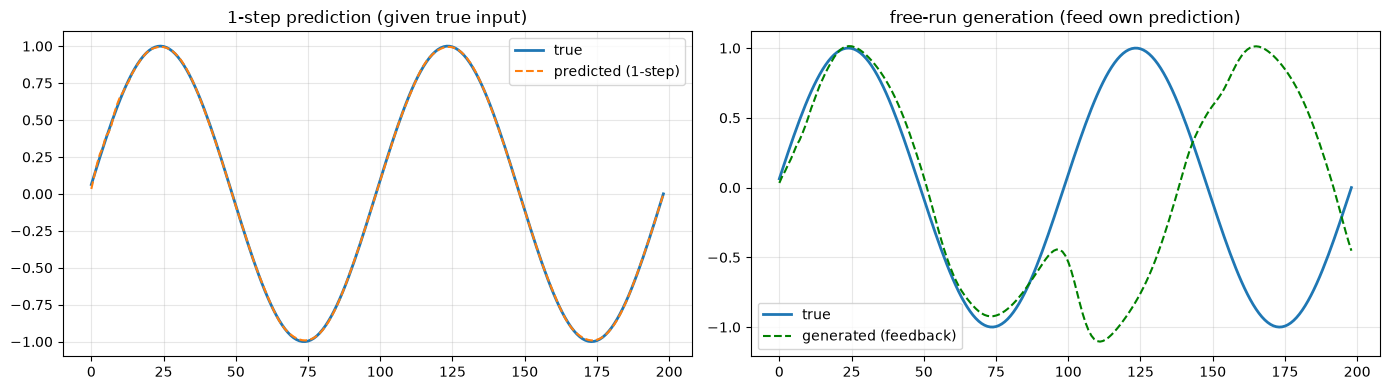

In [17]:
# 学習した RNN で予測
model.reset_state()
pred_1step = []
with no_grad():
    for t in range(len(seq) - 1):
        y = model(Variable(seq[t].reshape(1, 1)))
        pred_1step.append(float(y.data.reshape(-1)[0]))

# 予測値を次の入力にして「未来を生成」する
model.reset_state()
generated = []
with no_grad():
    x = Variable(seq[0].reshape(1, 1))   # 最初の値だけ与える
    for t in range(len(seq) - 1):
        y = model(x)
        val = float(y.data.reshape(-1)[0])
        generated.append(val)
        x = Variable(np.array(val).reshape(1, 1))   # 予測を次の入力に

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(seq[1:], label='true', lw=2)
axes[0].plot(pred_1step, '--', label='predicted (1-step)')
axes[0].set_title('1-step prediction (given true input)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(seq[1:], label='true', lw=2)
axes[1].plot(generated, '--', label='generated (feedback)', color='green')
axes[1].set_title('free-run generation (feed own prediction)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


左：各時刻で本物の値を入力に使った 1 ステップ予測 → よく一致  
右：自分の予測を次の入力にして未来を生成 → サイン波を自力で描き続ける  

左のグラフでは、RNN が次の値をほぼ正確に予測できている。右のグラフは、最初の 1 点だけを与え、あとは自分の予測を次の入力にフィードバックして未来を生成したものである。右のグラフでは、最初は元のグラフと一致しているが、予測を繰り返すごとにだんだんと元の値との乖離が大きくなっている。

> ステップ 59 のまとめ
> - RNN は隠れ状態 $h_t = \tanh(x_t W_x + h_{t-1} W_h + b)$ で記憶を引き継ぐ。
> - 長い時系列では計算グラフが伸びるので、`unchain_backward()` で切る (Truncated BPTT)。
> - サイン波の次の値を予測できた。

---
# ステップ 60：LSTM とデータローダ

RNN には弱点がある。長い時系列になると、昔の情報を忘れてしまう (「勾配消失」という現象で、遠い過去の情報がうまく学習できない) のである。これを改善したのが LSTM (Long Short-Term Memory) である。

## 60.2 LSTM とは ― ゲートの仕組み

LSTM は、記憶セル (cell) という長期記憶の通り道と、3 つのゲートを持つ。ゲートは「情報をどれだけ通すか」を 0〜1 で調整する仕組みである (sigmoid で実現)。

LSTM の計算は次の式である (少し複雑だが、1 つずつ見ると分かる)。

$$ f = \sigma(x_t W_x^{(f)} + h_{t-1} W_h^{(f)} + b^{(f)}) \quad \text{(忘却ゲート)} $$
$$ g = \tanh(x_t W_x^{(g)} + h_{t-1} W_h^{(g)} + b^{(g)}) \quad \text{(新しい情報)} $$
$$ i = \sigma(x_t W_x^{(i)} + h_{t-1} W_h^{(i)} + b^{(i)}) \quad \text{(入力ゲート)} $$
$$ o = \sigma(x_t W_x^{(o)} + h_{t-1} W_h^{(o)} + b^{(o)}) \quad \text{(出力ゲート)} $$
$$ c_t = f \odot c_{t-1} + g \odot i \quad \text{(記憶セルの更新)} $$
$$ h_t = o \odot \tanh(c_t) \quad \text{(隠れ状態の出力)} $$

- 忘却ゲート $f$：前の記憶 $c_{t-1}$ を「どれだけ忘れるか」(0＝全部忘れる、1＝全部覚える)。
- 新しい情報 $g$：今の入力から作る新しい候補情報。
- 入力ゲート $i$：新しい情報 $g$ を「どれだけ取り込むか」。
- 出力ゲート $o$：記憶セルから「どれだけ出力するか」。
- $\odot$ は要素ごとの積。

式の気持ち：記憶セル $c$ という「ノート」に、忘却ゲートで古い記憶を消し、入力ゲートで新しい記憶を書き込む。この「選択的な記憶」により、大事な情報を長く保持できる。

## 実装の工夫 ― 4 つの重みをまとめる

4 つのゲート ($f, g, i, o$) は、どれも $x_t W_x + h_{t-1} W_h + b$ という同じ形の計算である。そこで、4 つ分の重みを 1 つの大きな行列にまとめて一度に計算し、あとで 4 つに分割する。これで計算が効率化される (重みの形状が $(D, 4H)$ になる)。

In [18]:
class LSTMLayer(Layer):
    def __init__(self, hidden_size, in_size=None):
        super().__init__()
        H = hidden_size
        # 4 つのゲート分の重みをまとめて持つ (出力サイズ 4H)
        self.x2h = LinearLayer(4 * H, in_size=in_size)         # x → 4 ゲート
        self.h2h = LinearLayer(4 * H, in_size=in_size, nobias=True)  # h → 4 ゲート
        self.h = None   # 隠れ状態
        self.c = None   # 記憶セル
        self.H = H

    def reset_state(self):
        self.h = None
        self.c = None

    def forward(self, x):
        # 4 ゲート分をまとめて計算
        if self.h is None:
            A = self.x2h(x)
        else:
            A = self.x2h(x) + self.h2h(self.h)
        H = self.H
        # まとめた結果 A を 4 つに分割 (f, g, i, o)
        f = sigmoid(A[:, 0:H])       # 忘却ゲート
        g = tanh(A[:, H:2*H])        # 新しい情報
        i = sigmoid(A[:, 2*H:3*H])   # 入力ゲート
        o = sigmoid(A[:, 3*H:4*H])   # 出力ゲート

        # 記憶セルの更新
        if self.c is None:
            c_new = g * i                        # 最初は前の記憶が無い
        else:
            c_new = f * self.c + g * i           # 忘れる＋新しく覚える
        h_new = o * tanh(c_new)                  # 隠れ状態を出力

        self.h, self.c = h_new, c_new
        return h_new

# 動作確認
np.random.seed(0)
lstm = LSTMLayer(hidden_size=8)
x = Variable(np.random.randn(1, 4).astype(np.float32))
h1 = lstm(x)
h2 = lstm(Variable(np.random.randn(1, 4).astype(np.float32)))
print("LSTM 隠れ状態 h：", h1.shape, ", 記憶セル c：", lstm.c.shape)
print("→ h (外部へ出力) と c (内部の長期記憶) の 2 つを持つのが LSTM の特徴")


LSTM 隠れ状態 h： (1, 8) , 記憶セル c： (1, 8)
→ h (外部へ出力) と c (内部の長期記憶) の 2 つを持つのが LSTM の特徴


## 60.1 時系列データのためのデータローダ (概念)

時系列データを扱う際は、専用のデータローダ SeqDataLoader を使う。通常の `DataLoader` はデータをシャッフルするが、時系列では順番が命なのでシャッフルできない。代わりに、長い時系列を複数の「開始位置」から並行して読み出す工夫をする (詳細は書籍参照)。ここでは概念の紹介に留める。

## LSTM モデルでサイン波を予測 (RNN と比較)

LSTM を使ったモデルを作り、RNN と同じサイン波予測をさせてみる。

In [35]:
class SimpleLSTM(Model):
    def __init__(self, hidden_size, out_size):
        super().__init__()
        self.lstm = LSTMLayer(hidden_size)
        self.fc = LinearLayer(out_size)
    def reset_state(self):
        self.lstm.reset_state()
    def forward(self, x):
        h = self.lstm(x)
        return self.fc(h)

# サイン波データ (ステップ 59 と同じ)
np.random.seed(0)
seq = np.sin(np.linspace(0, 4 * np.pi, 200)).astype(np.float32)

# LSTM を学習
np.random.seed(0)
model = SimpleLSTM(hidden_size=50, out_size=1)
optimizer = Adam(alpha=0.01).setup(model)   # Adam で効率よく学習
bptt_length = 30

loss_history = []
for epoch in range(50):
    model.reset_state()
    loss, count = 0, 0
    for t in range(len(seq) - 1):
        x = Variable(seq[t].reshape(1, 1))
        target = Variable(seq[t + 1].reshape(1, 1))
        y = model(x)
        loss = loss + mean_squared_error(y, target)
        count += 1
        if count % bptt_length == 0 or t == len(seq) - 2:
            model.cleargrads()
            loss.backward()
            loss.unchain_backward()
            optimizer.update()
            loss = 0
    model.reset_state()
    with no_grad():
        total = 0
        for t in range(len(seq) - 1):
            y = model(Variable(seq[t].reshape(1, 1)))
            total += (float(y.data.reshape(-1)[0]) - seq[t + 1]) ** 2
    loss_history.append(total / (len(seq) - 1))
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1}: loss = {loss_history[-1]:.5f}")

print(f"\nLSTM 最終 loss：{loss_history[-1]:.5f}")


epoch 10: loss = 0.00020
epoch 20: loss = 0.00004
epoch 30: loss = 0.00002
epoch 40: loss = 0.00002
epoch 50: loss = 0.00003

LSTM 最終 loss：0.00003


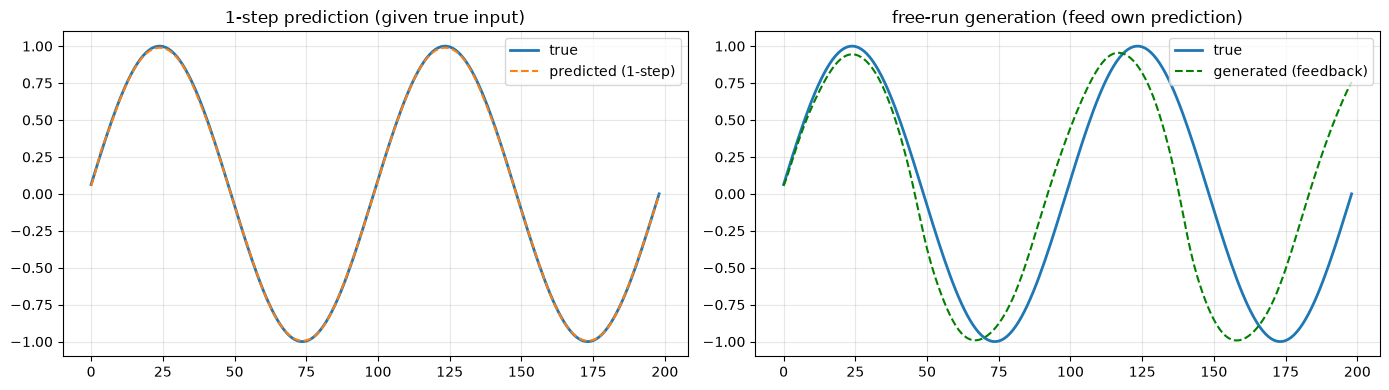

In [36]:
# 学習した RNN で予測
model.reset_state()
pred_1step = []
with no_grad():
    for t in range(len(seq) - 1):
        y = model(Variable(seq[t].reshape(1, 1)))
        pred_1step.append(float(y.data.reshape(-1)[0]))

# 予測値を次の入力にして「未来を生成」する
model.reset_state()
generated = []
with no_grad():
    x = Variable(seq[0].reshape(1, 1))   # 最初の値だけ与える
    for t in range(len(seq) - 1):
        y = model(x)
        val = float(y.data.reshape(-1)[0])
        generated.append(val)
        x = Variable(np.array(val).reshape(1, 1))   # 予測を次の入力に

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(seq[1:], label='true', lw=2)
axes[0].plot(pred_1step, '--', label='predicted (1-step)')
axes[0].set_title('1-step prediction (given true input)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(seq[1:], label='true', lw=2)
axes[1].plot(generated, '--', label='generated (feedback)', color='green')
axes[1].set_title('free-run generation (feed own prediction)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


LSTM もサイン波を正しく予測できた。

LSTM は特に『長期的な依存関係』が重要なデータ (長い文章など) で威力を発揮する。

> ステップ 60 のまとめ
> - LSTM は記憶セル $c$ と 3 つのゲート (忘却・入力・出力) で長期記憶を実現。
> - 4 つのゲートの重みをまとめて $(D, 4H)$ の行列で効率計算。
> - 時系列データはシャッフルできないので専用の SeqDataLoader を使う。
> - LSTM でもサイン波を予測でき、長期依存が重要な問題で RNN より強い。

---
# 発展：PyTorch での書き方

今回実装した CNN・RNN・LSTM は、PyTorch にすべて対応物がある。DeZero で中身を理解したうえで PyTorch を見ると、各クラスが何をしているか明確に分かる。

> この環境に PyTorch が無い場合、下のセルは自動でスキップして説明だけ表示する。

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- CNN (DeZero: conv2d_simple / pooling_simple) ---
conv = nn.Conv2d(1, 8, kernel_size=3, padding=1)   # DeZero: conv2d_simple
pool = nn.MaxPool2d(2, 2)                            # DeZero: pooling_simple
x = torch.randn(1, 1, 8, 8)
h = pool(F.relu(conv(x)))
print(f"[CNN] Conv2d→ReLU→MaxPool: {tuple(x.shape)} → {tuple(h.shape)}")

# --- RNN (DeZero: RNNLayer) ---
rnn = nn.RNN(input_size=1, hidden_size=10, batch_first=True)  # DeZero: RNNLayer
x_seq = torch.randn(1, 20, 1)   # (バッチ, 時系列長, 特徴)
out, h_n = rnn(x_seq)
print(f"[RNN] nn.RNN：入力{tuple(x_seq.shape)} → 出力{tuple(out.shape)}")

# --- LSTM (DeZero: LSTMLayer) ---
lstm = nn.LSTM(input_size=1, hidden_size=10, batch_first=True)  # DeZero: LSTMLayer
out, (h_n, c_n) = lstm(x_seq)
print(f"[LSTM] nn.LSTM：出力{tuple(out.shape)}, 記憶セル{tuple(c_n.shape)}")


ModuleNotFoundError: No module named 'torch'

今回実装した層は、PyTorch の nn.Conv2d/nn.RNN/nn.LSTM に対応する。

### DeZero と PyTorch の対応表

| 概念 | DeZero (手作り) | PyTorch |
|---|---|---|
| 畳み込み | `conv2d_simple` (im2col) | `nn.Conv2d` |
| プーリング | `pooling_simple` | `nn.MaxPool2d` |
| RNN | `RNNLayer` | `nn.RNN` |
| LSTM | `LSTMLayer` | `nn.LSTM` |
| 有名 CNN | VGG 風の自作 CNN | `torchvision.models.vgg16` |
| つながりを切る | `unchain_backward()` | `tensor.detach()` |

PyTorch の `nn.Conv2d` の裏では im2col 的な高速化が、`nn.LSTM` の裏では今回実装したゲートの計算が行われている。`tensor.detach()` (PyTorch で計算グラフを切る操作) も、DeZero の `unchain_backward()` と同じ役割である。DeZero を手作りしたことで、これらが完全に理解できた。

---
# まとめ

ステップ 57〜60 で、DeZero は CNN・RNN・LSTM を備えた、本格的なディープラーニングフレームワークとして完成した。

### 今回 (57〜60) の到達点
1. ステップ 57 (CNN 実装) im2col で畳み込みを行列の積に変換し、`conv2d`/`pooling` を高速実装。
2. ステップ 58 (VGG16) 有名 CNN の規則的な構造を理解し、VGG 風の小型 CNN で手書き数字を分類。
3. ステップ 59 (RNN) 隠れ状態で記憶を引き継ぐ RNN を実装。`unchain_backward` による Truncated BPTT。サイン波を予測・生成。
4. ステップ 60 (LSTM) ゲートと記憶セルで長期記憶を実現する LSTM を実装。

### これまでの内容の振り返り
```
第 1 ステージ：微分を自動で求める
  Variable と Function、backward による自動微分
       ↓
第 2 ステージ：自然なコードで表現する
  可変長引数、演算子オーバーロード、メモリ管理
       ↓
第 3 ステージ：高階微分を実現する
  逆伝播を計算グラフ化 (double backprop)、ニュートン法
       ↓
第 4 ステージ：ニューラルネットワークを作る
  テンソル対応、Layer/Model/Optimizer、MNIST 学習
       ↓
第 5 ステージ：DeZero で挑む
  GPU 対応・保存・Dropout → CNN → 【今回】CNN/RNN/LSTM 実装
       ↓
        DeZero の完成！
```

小さな `Variable` クラスから始めた DeZero が、現代ディープラーニングの主要技術 (CNN・RNN・LSTM) をすべて動かせる、PyTorch に匹敵する設計のフレームワークになった。

### DeZero を実装する意義
ディープラーニングフレームワークを「使う」だけでなく「作る」ことで、その内部を完全に理解することを目指した。
- `backward()` が何をしているか (バックプロパゲーション)
- `nn.Linear`/`nn.Conv2d`/`nn.LSTM` の中身
- `optimizer.step()`、`model.eval()`、`detach()` の意味
- 高階微分や自動微分の仕組み

これらは、今後 PyTorch や TensorFlow を使うときにその裏側で何が起きているかを理解する手助けになる。